In [1]:
from pymatgen.analysis.wulff import WulffShape
from pymatgen.core import Lattice
import matplotlib.pyplot as plt

# Mg2Zn11 cubic lattice (Pm-3, a = 8.71 A)
lattice = Lattice.cubic(8.710)

miller_indices = [
    (1, 0, 0),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1),
]

surface_energies = [
    0.6271,  # (100)
    0.6320,  # (110)
    0.5593,  # (111)
    0.5975,  # (210)
    0.5991,  # (211)
]

wulff = WulffShape(lattice, miller_indices, surface_energies)

print(f"Wulff shape summary:")
print(f"  Weighted surface energy: {wulff.weighted_surface_energy:.4f} J/m²")
print(f"  Anisotropy: {wulff.anisotropy:.4f}")
print(f"  Shape factor: {wulff.shape_factor:.4f}")

print(f"\n  {'Plane':>8} {'γ (J/m²)':>10} {'Area frac':>10}")
print("  " + "-" * 32)
for facet, energy in zip(miller_indices, surface_energies):
    area_frac = wulff.area_fraction_dict.get(tuple(facet), 0)
    print(f"  {str(facet):>8} {energy:>10.4f} {area_frac:>10.4f}")

Wulff shape summary:
  Weighted surface energy: 0.5860 J/m²
  Anisotropy: 0.0335
  Shape factor: 4.9788

     Plane   γ (J/m²)  Area frac
  --------------------------------
  (1, 0, 0)     0.6271     0.0341
  (1, 1, 0)     0.6320     0.0000
  (1, 1, 1)     0.5593     0.3339
  (2, 1, 0)     0.5975     0.4980
  (2, 1, 1)     0.5991     0.1339


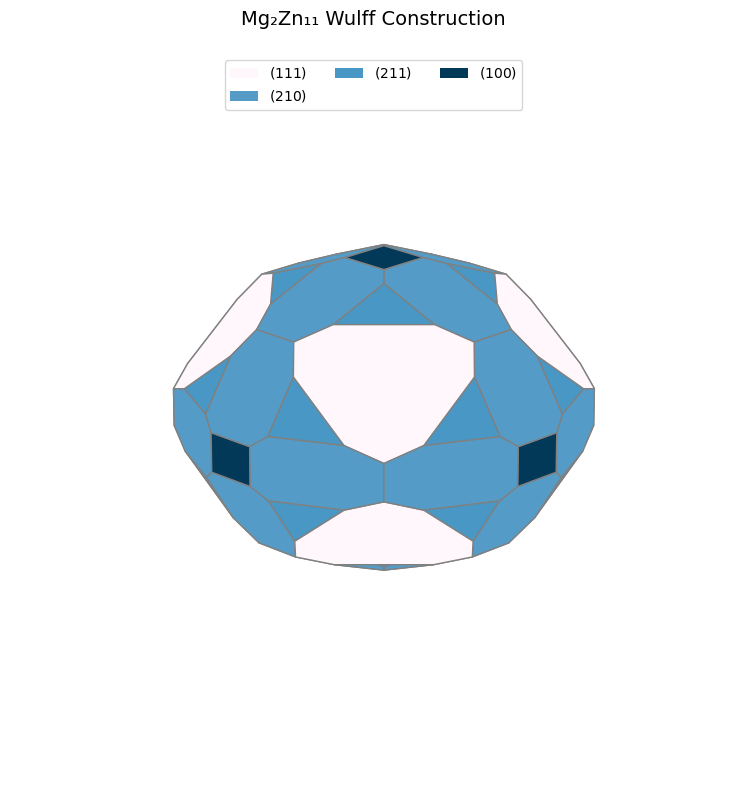

In [2]:
ax = wulff.get_plot()
fig = ax.get_figure()
fig.set_size_inches(8, 8)
ax.view_init(elev=20, azim=45)
plt.title("Mg₂Zn₁₁ Wulff Construction", fontsize=14, pad=20)
plt.tight_layout()
plt.show()